In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(r"C:\Users\admin\OneDrive\Desktop\Shraddha imp\Retail Sales\retail_sales.csv")
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub_category,product_name,sales
0,1,CA-2017-152156,08-11-2017,11-11-2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08-11-2017,11-11-2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12-06-2017,16-06-2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11-10-2016,18-10-2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11-10-2016,18-10-2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [5]:
df.shape

(9800, 18)

In [17]:
df.isnull().sum()

row_id            0
order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_id       0
customer_name     0
segment           0
country           0
city              0
state             0
postal_code      11
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
dtype: int64

In [20]:
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst= True)
df['ship_date'] = pd.to_datetime(df['ship_date'], dayfirst= True)

In [22]:
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
df['month_name'] = df['order_date'].dt.month_name()

In [23]:
df[['order_date','year','month','month_name']].head()

,order_date,year,month,month_name
0,2017-11-08,2017,11,November
1,2017-11-08,2017,11,November
2,2017-06-12,2017,6,June
3,2016-10-11,2016,10,October
4,2016-10-11,2016,10,October


In [25]:
df['sales'].sum()

np.float64(2261536.7827)

In [26]:
df['sales'].mean()

np.float64(230.76905945918367)

In [27]:
df['order_id'].nunique()

4922

In [28]:
df['customer_id'].nunique()

793

In [48]:
monthly_sales = df.groupby(['year','month'])['sales'].sum().reset_index()

monthly_sales

,year,month,sales
0,2015,1,14205.7070
1,2015,2,4519.8920
2,2015,3,55205.7970
3,2015,4,27906.8550
4,2015,5,23644.3030
5,2015,6,34322.9356
6,2015,7,33781.5430
7,2015,8,27117.5365
8,2015,9,81623.5268
9,2015,10,31453.3930


In [49]:
monthly_sales['date'] = pd.to_datetime(monthly_sales[['year','month']].assign(day=1))

In [50]:
monthly_sales.head()

,year,month,sales,date
0,2015,1,14205.707,2015-01-01
1,2015,2,4519.892,2015-02-01
2,2015,3,55205.797,2015-03-01
3,2015,4,27906.855,2015-04-01
4,2015,5,23644.303,2015-05-01


In [35]:
df.groupby('city')['sales'].sum().sort_values(ascending= False).head(10)

city
New York City    252462.5470
Los Angeles      173420.1810
Seattle          116106.3220
San Francisco    109041.1200
Philadelphia     108841.7490
Houston           63956.1428
Chicago           47820.1330
San Diego         47521.0290
Jacksonville      44713.1830
Detroit           42446.9440
Name: sales, dtype: float64

In [36]:
df.groupby('state')['sales'].sum().sort_values(ascending= False).head(10)

state
California      446306.4635
New York        306361.1470
Texas           168572.5322
Washington      135206.8500
Pennsylvania    116276.6500
Florida          88436.5320
Illinois         79236.5170
Michigan         76136.0740
Ohio             75130.3500
Virginia         70636.7200
Name: sales, dtype: float64

In [29]:
df.groupby('region')['sales'].sum().sort_values(ascending= False)

region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: sales, dtype: float64

In [37]:
df.groupby('category')['sales'].sum().sort_values(ascending= False)

category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: sales, dtype: float64

In [38]:
df.groupby('sub_category')['sales'].sum().sort_values(ascending= False)

sub_category
Phones         327782.4480
Chairs         322822.7310
Storage        219343.3920
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    164186.7000
Copiers        146248.0940
Bookcases      113813.1987
Appliances     104618.4030
Furnishings     89212.0180
Paper           76828.3040
Supplies        46420.3080
Art             26705.4100
Envelopes       16128.0460
Labels          12347.7260
Fasteners        3001.9600
Name: sales, dtype: float64

In [31]:
df.groupby('product_name')['sales'].sum().sort_values(ascending= False). head(10)

product_name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: sales, dtype: float64

In [40]:
df.groupby('segment')['sales'].sum()

segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: sales, dtype: float64

In [41]:
df.groupby('year')['sales'].sum()

year
2015    479856.2081
2016    459436.0054
2017    600192.5500
2018    722052.0192
Name: sales, dtype: float64

In [44]:
df.groupby('month')['sales'].sum()

month
1      94291.6296
2      59371.1154
3     197573.5872
4     136283.0006
5     154086.7237
6     145837.5233
7     145535.6890
8     157315.9270
9     300103.4117
10    199496.2947
11    350161.7110
12    321480.1695
Name: sales, dtype: float64

<Axes: title={'center': 'Sales by Region'}, xlabel='region'>

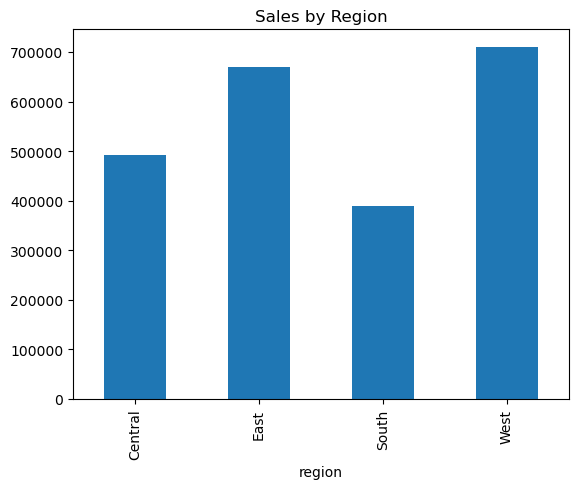

In [32]:
df.groupby('region')['sales'].sum().plot(kind='bar', title='Sales by Region')

<Axes: title={'center': 'Monthly Sales Trend'}, xlabel='month'>

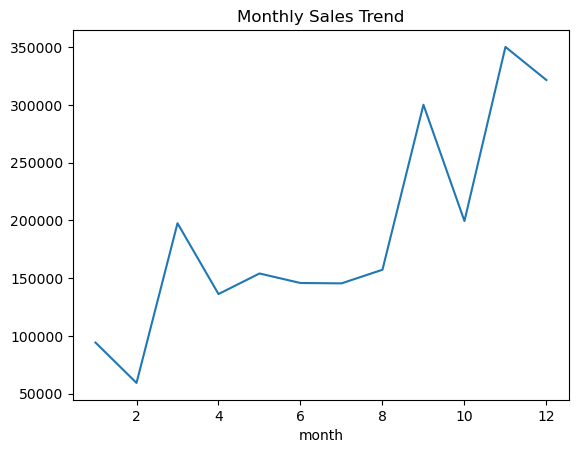

In [33]:
df.groupby('month')['sales'].sum().plot(title='Monthly Sales Trend')

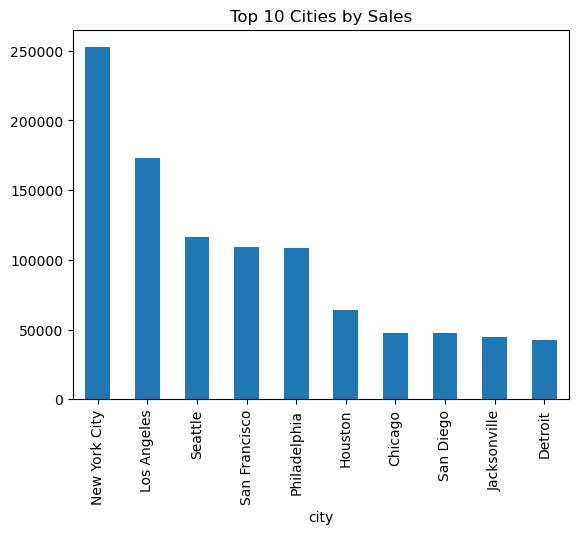

In [45]:
df.groupby('city')['sales'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Cities by Sales")
plt.show()

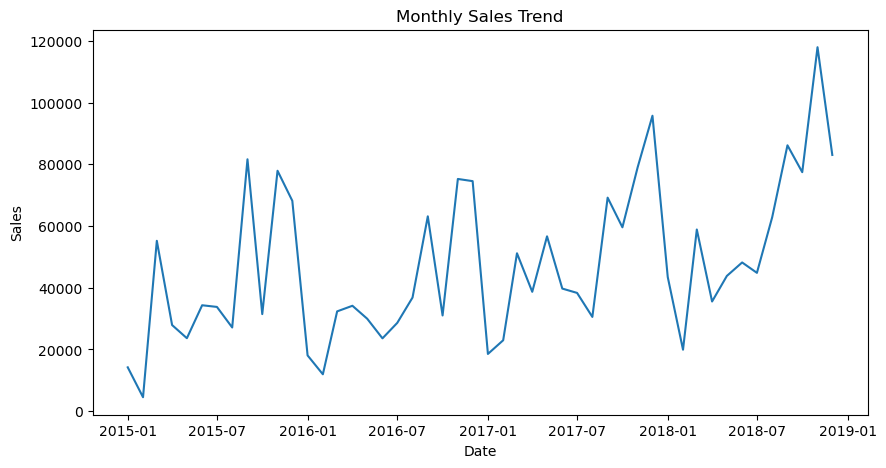

In [51]:
plt.figure(figsize=(10,5))
plt.plot(monthly_sales['date'], monthly_sales['sales'])
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

In [52]:
!pip install prophet

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.1 MB 1.9 MB/s eta 0:00:06
   --- ------------------------------------ 1.0/12.1 MB 2.0 MB/s eta 0:00:06
   ---- ----------------------------------- 1.3/12.1 MB 2.1 MB/s eta 0:00:06
   ------ --------------------------------- 1.8/12.1 MB 1.9 MB/s eta 0:00:06
   ------ --------------------------------- 2.1/12.1 MB 2.0 MB/s eta 0:00:06
   -------- ------------------------------- 2.6/12.1 MB 2.0 MB/s eta 0:00:05
   ---------- ----------------------------- 3.1/12.1 MB 2.0 MB/s eta 0:00:05
   ------------ --------------------------- 3.7/12.1 MB 2.1 MB/s eta 0:00:05
   ------------- -------------------------- 4.2/12.1 MB 2.2 MB/s eta 0:00:04
   -------------- ------------------------- 4.5/12.1 MB 2.2 MB/s eta 0:00:04
   ---------------- ----------------------- 5.0/12.1 MB 2.0 MB/s eta 0:00:04
   ----------

In [53]:
from prophet import Prophet

forecast_df = monthly_sales[['date','sales']]

forecast_df = forecast_df.rename(columns={
    'date':'ds',
    'sales':'y'
})

forecast_df.head()

,ds,y
0,2015-01-01,14205.707
1,2015-02-01,4519.892
2,2015-03-01,55205.797
3,2015-04-01,27906.855
4,2015-05-01,23644.303


In [54]:
model = Prophet()

model.fit(forecast_df)

21:15:24 - cmdstanpy - INFO - Chain [1] start processing
21:15:25 - cmdstanpy - INFO - Chain [1] done processing


In [55]:
future = model.make_future_dataframe(periods=12, freq='M')

forecast = model.predict(future)

forecast[['ds','yhat','yhat_lower','yhat_upper']].tail()

C:\Users\admin\anaconda3\Lib\site-packages\prophet\forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


,ds,yhat,yhat_lower,yhat_upper
55,2019-07-31,46565.562030,37867.956663,56012.596367
56,2019-08-31,118629.850636,109526.645574,128310.741823
57,2019-09-30,65062.294896,56011.305221,74122.033353
58,2019-10-31,120758.790929,111182.919953,130048.620449
59,2019-11-30,76224.295407,66801.698151,85841.601366


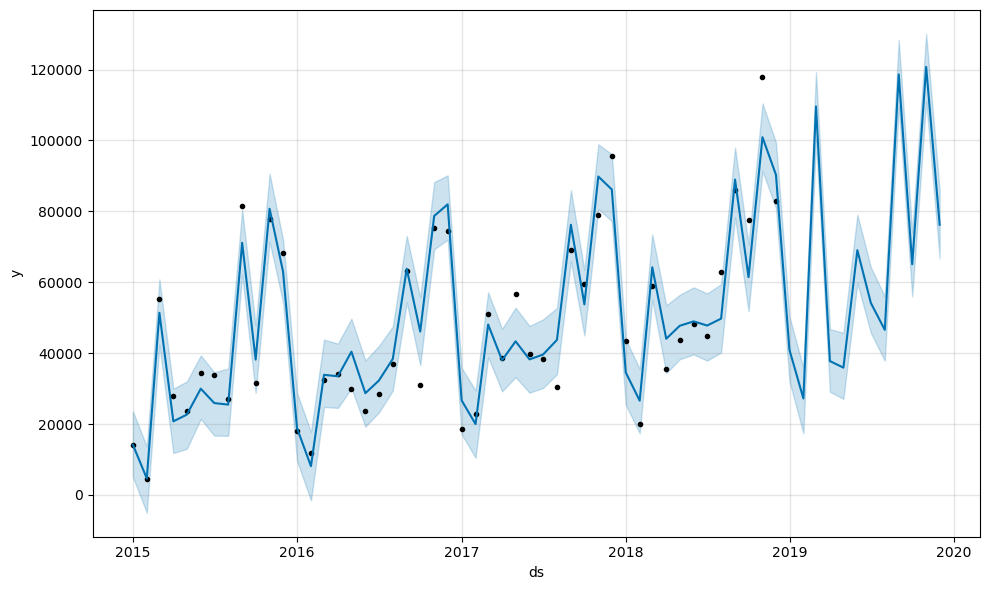

In [58]:
fig1= model.plot(forecast)

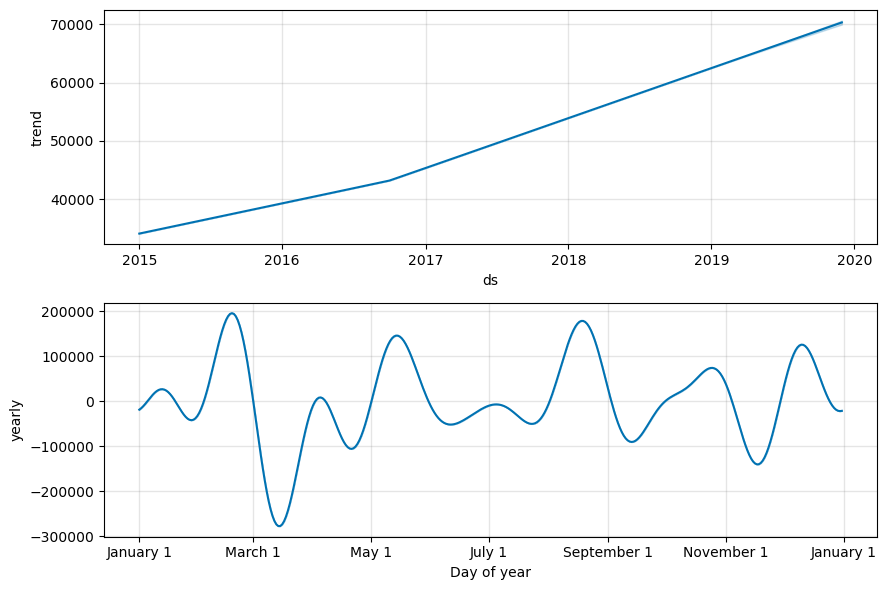

In [60]:
fig2= model.plot_components(forecast)

In [61]:
forecast.to_csv("sales_forecast.csv", index=False)

In [6]:
df.to_csv("retail_sales_cleaned.csv", index=False)